# HDB Resale Price: A Hedonic Pricing Model

This notebook models Singapore HDB resale flat prices using a hedonic
pricing framework: price as a function of a flat's physical attributes
(floor area, remaining lease, storey) and its location (town, distance to
the nearest MRT station).

**Framing note:** this is an *inference* problem, not a prediction
problem. Following Rosen's (1974) hedonic framework, the goal is to recover
interpretable marginal prices for each attribute (e.g. the implicit price
of a square metre, or a year of remaining lease) — not to minimize
forecast error. Specification correctness and coefficient interpretability
are prioritized accordingly; a separate out-of-sample check is included at
the end as a robustness test, not as the primary objective.

## 1. Setup

In [1]:
import os
import re
import json
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.metrics import r2_score, root_mean_squared_error


## 2. Data Loading

Two source files (both from data.gov.sg) plus a cached geocoding backup
(see Section 3) so the notebook doesn't need to re-query OneMap on every
run.

In [2]:
HDB_DATA_PATH = "/Users/aryans/Desktop/HDB:DATA/DATA/ResaleflatpricesbasedonregistrationdatefromJan2017onwards.xlsx"
MRT_DATA_PATH = "/Users/aryans/Desktop/HDB:DATA/DATA/LTAMRTStationExitGEOJSON.geojson"

hdb_df = pd.read_excel(HDB_DATA_PATH)
hdb_df['address'] = hdb_df['block'].astype(str) + " " + hdb_df['street_name']

unique_addresses_raw = pd.DataFrame(hdb_df['address'].unique(), columns=['address'])
print(f"Total HDB transactions: {len(hdb_df)}")
print(f"Unique buildings to geocode: {len(unique_addresses_raw)}")

with open(MRT_DATA_PATH, 'r') as f:
    mrt_data = json.load(f)

mrt_list = []
for feature in mrt_data['features']:
    lon, lat = feature['geometry']['coordinates']
    station_name = feature['properties']['STATION_NA']
    mrt_list.append({'station_name': station_name, 'mrt_lat': lat, 'mrt_lon': lon})

mrt_df = pd.DataFrame(mrt_list).drop_duplicates(subset=['station_name']).reset_index(drop=True)
print(f"Unique MRT stations loaded: {len(mrt_df)}")


Total HDB transactions: 240073
Unique buildings to geocode: 9744
Unique MRT stations loaded: 190


## 3. Geocoding HDB Addresses

Token is read from an environment variable rather than hardcoded, since
this notebook is intended to eventually be public. Set it before running:

```bash
export ONEMAP_TOKEN="your_token_here"
```

All 9,744 addresses are already geocoded and cached in
`hdb_coordinates_backup.csv` from a previous run, so this cell resumes
instantly rather than re-querying the API.

In [3]:
ONEMAP_TOKEN = os.environ.get("ONEMAP_TOKEN")
if ONEMAP_TOKEN:
    ONEMAP_TOKEN = ONEMAP_TOKEN.replace('\n', '').replace('\r', '').strip()

def validate_jwt_shape(t):
    parts = t.strip().split(".")
    if len(parts) != 3:
        raise ValueError(f"Token does not look like a valid JWT (expected 3 segments, got {len(parts)}).")
    allowed = set("ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789-_")
    for i, part in enumerate(parts):
        bad = set(part) - allowed
        if bad:
            raise ValueError(f"Token segment {i} has invalid characters {bad} - re-copy it as plain text.")

headers = {
    "User-Agent": ("Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
                    "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36")
}
if ONEMAP_TOKEN:
    validate_jwt_shape(ONEMAP_TOKEN)
    headers["Authorization"] = f"Bearer {ONEMAP_TOKEN}"

CACHE_PATH = "hdb_coordinates_backup.csv"
unique_addresses = unique_addresses_raw.copy()
unique_addresses['hdb_lat'] = np.nan
unique_addresses['hdb_lon'] = np.nan

if os.path.exists(CACHE_PATH):
    cached = pd.read_csv(CACHE_PATH)
    unique_addresses = unique_addresses.merge(cached, on='address', how='left', suffixes=('', '_cached'))
    unique_addresses['hdb_lat'] = unique_addresses['hdb_lat_cached'].combine_first(unique_addresses['hdb_lat'])
    unique_addresses['hdb_lon'] = unique_addresses['hdb_lon_cached'].combine_first(unique_addresses['hdb_lon'])
    unique_addresses = unique_addresses.drop(columns=['hdb_lat_cached', 'hdb_lon_cached'])

pending = unique_addresses[unique_addresses['hdb_lat'].isna()]
print(f"Already geocoded: {len(unique_addresses) - len(pending)}")
print(f"Remaining to geocode: {len(pending)}")

def geocode_address(address):
    url = (f"https://www.onemap.gov.sg/api/common/elastic/search"
           f"?searchVal={address}&returnGeom=Y&getAddrDetails=Y&pageNum=1")
    try:
        response = requests.get(url, headers=headers, timeout=10)
        if response.status_code == 200:
            data = response.json()
            if data.get('found', 0) > 0:
                r = data['results'][0]
                return float(r['LATITUDE']), float(r['LONGITUDE'])
    except Exception as e:
        print(f"Error on {address}: {e}")
    return np.nan, np.nan

for index, row in pending.iterrows():
    lat, lon = geocode_address(row['address'])
    unique_addresses.at[index, 'hdb_lat'] = lat
    unique_addresses.at[index, 'hdb_lon'] = lon
    time.sleep(0.25)

unique_addresses = unique_addresses.dropna(subset=['hdb_lat', 'hdb_lon']).reset_index(drop=True)
unique_addresses.to_csv(CACHE_PATH, index=False)
print(f"Geocoding complete. {len(unique_addresses)} addresses resolved.")


Already geocoded: 9744
Remaining to geocode: 0
Geocoding complete. 9744 addresses resolved.


## 4. Distance to Nearest MRT Station

In [4]:
def haversine_np(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    c = 2*np.arcsin(np.sqrt(a))
    return 6371.0 * c

hdb_lats = unique_addresses['hdb_lat'].values[:, np.newaxis]
hdb_lons = unique_addresses['hdb_lon'].values[:, np.newaxis]
mrt_lats = mrt_df['mrt_lat'].values
mrt_lons = mrt_df['mrt_lon'].values

dist_matrix = haversine_np(hdb_lons, hdb_lats, mrt_lons, mrt_lats)
min_indices = np.argmin(dist_matrix, axis=1)
unique_addresses['min_dist_mrt_km'] = dist_matrix[np.arange(len(dist_matrix)), min_indices]
unique_addresses['nearest_mrt'] = mrt_df['station_name'].values[min_indices]

final_df = hdb_df.merge(
    unique_addresses[['address', 'hdb_lat', 'hdb_lon', 'min_dist_mrt_km', 'nearest_mrt']],
    on='address', how='inner'
)
print(f"Final merged shape: {final_df.shape}")
final_df[['address', 'nearest_mrt', 'min_dist_mrt_km', 'resale_price']].head()


Final merged shape: (240073, 16)


,address,nearest_mrt,min_dist_mrt_km,resale_price
0,406 ANG MO KIO AVE 10,ANG MO KIO MRT STATION,0.985169,232000.0
1,108 ANG MO KIO AVE 4,MAYFLOWER MRT STATION,0.296947,250000.0
2,602 ANG MO KIO AVE 5,LENTOR MRT STATION,0.578448,262000.0
3,465 ANG MO KIO AVE 10,ANG MO KIO MRT STATION,0.916481,265000.0
4,601 ANG MO KIO AVE 5,LENTOR MRT STATION,0.544710,265000.0


## 5. Feature Engineering

Five derived features, computed once: parsed remaining lease, log price,
transaction year, cleaned town name, and a numeric storey midpoint (parsed
from `storey_range`, e.g. "07 TO 09" &rarr; 8.0).

In [5]:
def parse_lease_to_years(lease_str):
    if pd.isna(lease_str):
        return np.nan
    if isinstance(lease_str, (int, float)):
        return float(lease_str)
    years = re.findall(r'(\d+)\s*year', str(lease_str))
    months = re.findall(r'(\d+)\s*month', str(lease_str))
    total_years = float(years[0]) if years else 0.0
    total_years += float(months[0])/12.0 if months else 0.0
    return total_years

final_df['remaining_lease_years'] = final_df['remaining_lease'].apply(parse_lease_to_years)
final_df['log_price'] = np.log(final_df['resale_price'])
final_df['transaction_date'] = pd.to_datetime(final_df['month'], format='%Y-%m')
final_df['transaction_year'] = final_df['transaction_date'].dt.year
final_df['town_clean'] = final_df['town'].str.replace(' ', '_').str.replace('/', '_')
final_df['storey_midpoint'] = final_df['storey_range'].str.split(' TO ').apply(lambda x: (int(x[0])+int(x[1]))/2.0)

final_df.to_csv("hdb_resale_final_engineered.csv", index=False)
final_df[['resale_price','floor_area_sqm','remaining_lease_years','min_dist_mrt_km','storey_midpoint']].describe().round(2)


,resale_price,floor_area_sqm,remaining_lease_years,min_dist_mrt_km,storey_midpoint
count,240073.00,240073.00,240073.00,240073.00,240073.00
mean,534750.82,96.69,74.08,0.61,8.79
std,192238.63,24.01,14.33,0.38,5.96
min,140000.00,31.00,39.33,0.02,2.00
25%,390000.00,81.00,62.17,0.32,5.00
50%,503000.00,93.00,73.83,0.54,8.00
75%,640000.00,112.00,88.58,0.82,11.00
max,1728000.00,366.70,97.75,3.65,50.00


## 6. Exploratory Data Analysis

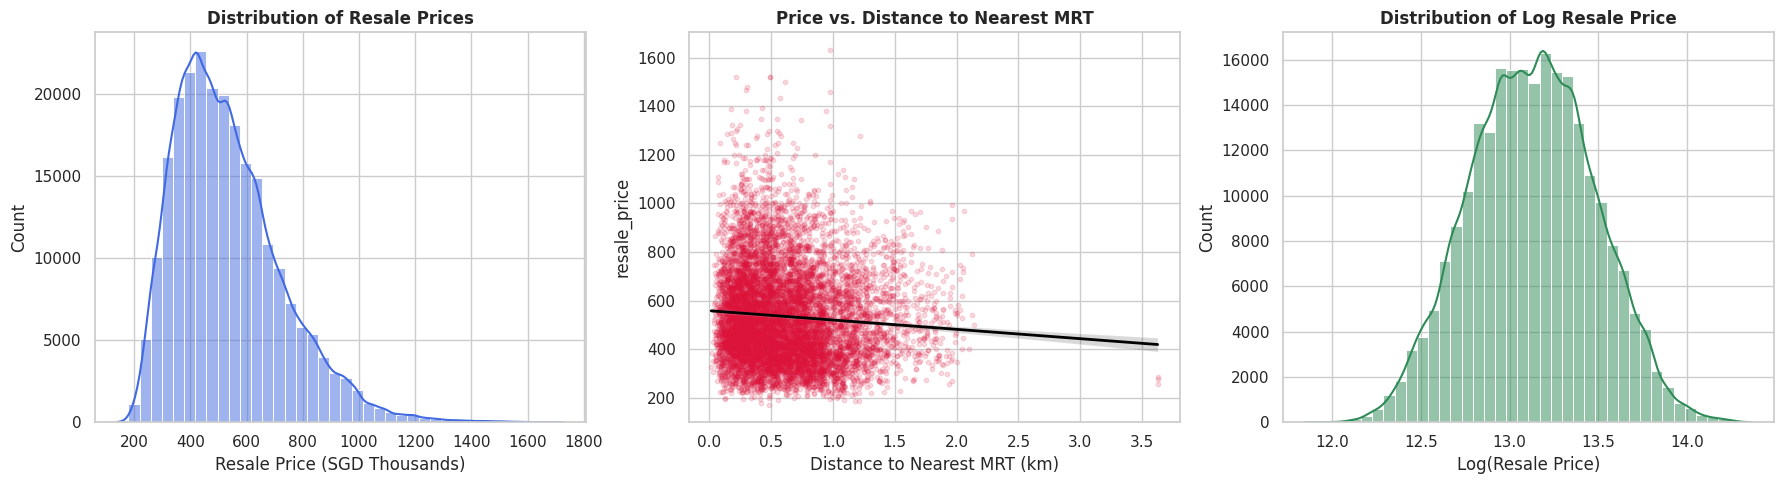

In [6]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(final_df['resale_price']/1e3, kde=True, ax=axes[0], color='royalblue', bins=40)
axes[0].set_title("Distribution of Resale Prices", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Resale Price (SGD Thousands)")

sample_df = final_df.sample(n=min(10000, len(final_df)), random_state=42)
sns.regplot(data=sample_df, x='min_dist_mrt_km', y=sample_df['resale_price']/1e3, ax=axes[1],
            color='crimson', scatter_kws={'alpha':0.15,'s':10}, line_kws={'color':'black','linewidth':2})
axes[1].set_title("Price vs. Distance to Nearest MRT", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Distance to Nearest MRT (km)")

sns.histplot(final_df['log_price'], kde=True, ax=axes[2], color='seagreen', bins=40)
axes[2].set_title("Distribution of Log Resale Price", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Log(Resale Price)")

plt.tight_layout()
plt.show()


**EDA discussion:**

Raw Price Distribution: The distribution of raw resale prices is heavily
right-skewed. While the bulk of transactions cluster between $350k and
$650k SGD, a long right tail extends well past $1.2 million — a classic
feature of housing market data where a small number of premium properties
pull the mean above the median.

MRT Proximity: The scatterplot confirms the expected negative relationship
between MRT distance and price — the "MRT premium" is visible directly in
the raw data, before any regression is run.

Log Transformation: The log transformation normalizes the distribution
into a symmetric, bell-shaped curve, virtually eliminating the right skew.
This makes `log_price` a much better-behaved dependent variable for OLS.

## 7. Model 1 — Baseline Linear Model

In [7]:
m1 = smf.ols(
    formula="resale_price ~ floor_area_sqm + remaining_lease_years + min_dist_mrt_km",
    data=final_df
).fit()
print(m1.summary2().tables[1])
print(f"R-squared: {m1.rsquared:.4f}")


                              Coef.     Std.Err.           t  P>|t|  \
Intercept             -93197.155898  2021.156029  -46.110817    0.0   
floor_area_sqm          4340.098239    12.884483  336.846919    0.0   
remaining_lease_years   3217.995104    21.609938  148.912744    0.0   
min_dist_mrt_km       -49134.363904   821.576021  -59.805012    0.0   

                             [0.025        0.975]  
Intercept             -97158.568894 -89235.742903  
floor_area_sqm          4314.844990   4365.351488  
remaining_lease_years   3175.640192   3260.350017  
min_dist_mrt_km       -50744.631435 -47524.096374  
R-squared: 0.3858


**Coefficient interpretation:**
- `floor_area_sqm`: each additional square metre of floor area is associated with a **+$4,340** change in resale price, holding lease and MRT distance constant.
- `remaining_lease_years`: each additional year of remaining lease is associated with a **+$3,218** change in resale price.
- `min_dist_mrt_km`: each additional kilometre from the nearest MRT station is associated with a **&minus;$49,134** change in resale price — as expected, negative.


## 8. Model 2 — Semi-Log with Town Fixed Effects (Dummy Variables)

In [8]:
m2 = smf.ols(
    formula="log_price ~ floor_area_sqm + remaining_lease_years + min_dist_mrt_km + C(town_clean)",
    data=final_df
).fit()
print(m2.summary2().tables[1].loc[['Intercept','floor_area_sqm','remaining_lease_years','min_dist_mrt_km']])
print(f"R-squared: {m2.rsquared:.4f}")


                           Coef.  Std.Err.            t  P>|t|     [0.025  \
Intercept              11.566467  0.003540  3267.130393    0.0  11.559528   
floor_area_sqm          0.009743  0.000019   505.769504    0.0   0.009705   
remaining_lease_years   0.010936  0.000036   300.603646    0.0   0.010865   
min_dist_mrt_km        -0.117196  0.001457   -80.463503    0.0  -0.120050   

                          0.975]  
Intercept              11.573406  
floor_area_sqm          0.009781  
remaining_lease_years   0.011008  
min_dist_mrt_km        -0.114341  
R-squared: 0.6346


**Interpretation:** the coefficient of &minus;0.117 on `min_dist_mrt_km`
implies roughly an **11.7% decrease** in resale price for each additional
kilometre from an MRT station. R-squared jumps substantially, from 0.3858
in Model 1 to **0.6346** — town fixed effects alone explain a large share
of price variation, confirming that macro-location captures real value a
raw MRT-distance metric can't.

## 9. Model 3 — Non-Linear Lease Decay and Storey Level

Two refinements over Model 2:
- A **quadratic** term on `remaining_lease_years`, since a 99-year lease
  should not decay at a constant dollar rate — financing constraints
  tighten as the lease shortens, so depreciation likely accelerates.
- `storey_midpoint`, parsed numerically from `storey_range`.


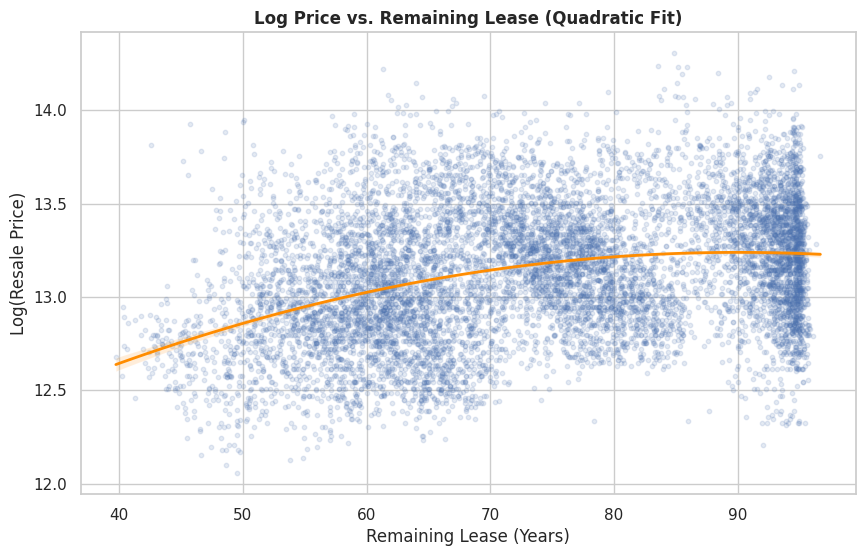

In [9]:
sample_df = final_df.sample(n=min(10000, len(final_df)), random_state=42)
plt.figure(figsize=(10, 6))
sns.regplot(data=sample_df, x='remaining_lease_years', y='log_price',
            scatter_kws={'alpha':0.15,'s':10}, line_kws={'color':'darkorange','linewidth':2}, order=2)
plt.title("Log Price vs. Remaining Lease (Quadratic Fit)", fontsize=12, fontweight='bold')
plt.xlabel("Remaining Lease (Years)")
plt.ylabel("Log(Resale Price)")
plt.show()


In [10]:
m3 = smf.ols(
    formula=("log_price ~ floor_area_sqm + remaining_lease_years + I(remaining_lease_years**2) "
             "+ storey_midpoint + min_dist_mrt_km + C(town_clean) + C(transaction_year)"),
    data=final_df
).fit()
print(m3.summary2().tables[1].loc[
    ['Intercept','floor_area_sqm','remaining_lease_years','I(remaining_lease_years ** 2)',
     'storey_midpoint','min_dist_mrt_km']
])
print(f"R-squared: {m3.rsquared:.4f}")


                                   Coef.  Std.Err.            t         P>|t|  \
Intercept                      11.185799  0.007331  1525.808271  0.000000e+00   
floor_area_sqm                  0.009960  0.000010   985.693776  0.000000e+00   
remaining_lease_years           0.014211  0.000208    68.308272  0.000000e+00   
I(remaining_lease_years ** 2)  -0.000021  0.000001   -15.228154  2.433502e-52   
storey_midpoint                 0.007824  0.000038   203.292781  0.000000e+00   
min_dist_mrt_km                -0.141614  0.000701  -202.019868  0.000000e+00   

                                  [0.025     0.975]  
Intercept                      11.171430  11.200168  
floor_area_sqm                  0.009940   0.009980  
remaining_lease_years           0.013803   0.014618  
I(remaining_lease_years ** 2)  -0.000024  -0.000018  
storey_midpoint                 0.007749   0.007900  
min_dist_mrt_km                -0.142988  -0.140240  
R-squared: 0.9167


**Interpretation:** adding transaction-year fixed effects, the
quadratic lease term, and storey level together lifts R-squared to
**0.9167**.

**Non-linear lease decay:** the linear lease term is positive (0.0142)
while the squared term is negative (&minus;0.000021, p<0.001) — a
concave-down relationship. Losing a year on a fresh 90-year lease barely
moves price; losing a year on a 50-year lease triggers a much steeper drop,
consistent with tightening bank financing and CPF withdrawal limits as
leases run down.

**Storey premium:** the coefficient on `storey_midpoint` (0.0078,
p<0.001) implies roughly a **0.8% price increase per floor**, holding
location and time constant.

**Spatial & physical attributes, fully controlled:** the MRT-distance
penalty strengthens to roughly **14.2%** per km once lease non-linearity
and storey are properly controlled for, and the floor-area premium settles
at roughly **1.0%** per additional square metre.

## 10. Model 4 — Adding an Interaction Term

Tests whether the MRT-distance price penalty differs by flat size, built
on top of the **full** Model 3 specification (quadratic lease + storey +
fixed effects) — not a simplified baseline — so this is a genuine test of
whether the interaction adds anything beyond the best model already
established.

In [11]:
m4 = smf.ols(
    formula=("log_price ~ floor_area_sqm * min_dist_mrt_km + remaining_lease_years "
             "+ I(remaining_lease_years**2) + storey_midpoint + C(town_clean) + C(transaction_year)"),
    data=final_df
).fit()
print(m4.summary2().tables[1].loc[
    ['Intercept','floor_area_sqm','min_dist_mrt_km','floor_area_sqm:min_dist_mrt_km',
     'remaining_lease_years','I(remaining_lease_years ** 2)','storey_midpoint']
])
print(f"R-squared: {m4.rsquared:.4f}")
print(f"R-squared change vs Model 3: {m3.rsquared:.6f} -> {m4.rsquared:.6f} (delta: {m4.rsquared - m3.rsquared:.6f})")


                                    Coef.  Std.Err.            t  \
Intercept                       11.166414  0.007427  1503.554750   
floor_area_sqm                   0.010205  0.000018   556.303758   
min_dist_mrt_km                 -0.104889  0.002400   -43.704848   
floor_area_sqm:min_dist_mrt_km  -0.000375  0.000023   -15.999509   
remaining_lease_years            0.014095  0.000208    67.745416   
I(remaining_lease_years ** 2)   -0.000020  0.000001   -14.703371   
storey_midpoint                  0.007818  0.000038   203.232415   

                                       P>|t|     [0.025     0.975]  
Intercept                       0.000000e+00  11.151858  11.180970  
floor_area_sqm                  0.000000e+00   0.010169   0.010241  
min_dist_mrt_km                 0.000000e+00  -0.109593  -0.100185  
floor_area_sqm:min_dist_mrt_km  1.379500e-57  -0.000421  -0.000329  
remaining_lease_years           0.000000e+00   0.013687   0.014502  
I(remaining_lease_years ** 2)   6.441523e

**Interpretation:** the interaction term is statistically significant
(p<0.001) with a negative coefficient, confirming that larger flats face a
*steeper* MRT-distance penalty than smaller ones — buyers are less willing
to pay the floor-area premium if the flat is far from a station.

However, tested properly against the full Model 3 baseline (not a
simplified one), the practical gain is negligible: R-squared moves from
0.9167 to 0.9168, a change of under 0.0001. On parsimony grounds, **Model
3 remains the preferred specification** — the interaction is real but too
small to justify the added complexity for interpretation purposes.

## 11. Model Comparison

In [12]:
results = pd.DataFrame({
    "Model": [
        "1. Linear (levels)",
        "2. Semi-log + Town FE",
        "3. Semi-log + Quadratic Lease + Storey + Town & Year FE",
        "4. Model 3 + Interaction",
    ],
    "R-squared": [m1.rsquared, m2.rsquared, m3.rsquared, m4.rsquared]
})
results


,Model,R-squared
0,1. Linear (levels),0.385813
1,2. Semi-log + Town FE,0.634605
2,3. Semi-log + Quadratic Lease + Storey + Town ...,0.916677
3,4. Model 3 + Interaction,0.916766


## 12. Out-of-Sample Validation (Temporal Holdout)

Because resale prices trend upward over time, a naive random train/test
split would let the model "see" future price levels during training —
exactly the kind of look-ahead leakage to avoid with time-ordered data.
Instead: train strictly on transactions through 2024, and test on 2025+ as
a genuine holdout the model never saw, using the full Model 3
specification.

In [13]:
train_df = final_df[final_df['transaction_year'] <= 2024].copy()
test_df = final_df[final_df['transaction_year'] >= 2025].copy()
print(f"Training set (<=2024): {len(train_df):,} transactions")
print(f"Holdout set (2025+): {len(test_df):,} transactions")

train_model = smf.ols(
    formula=("log_price ~ floor_area_sqm + remaining_lease_years + I(remaining_lease_years**2) "
             "+ storey_midpoint + min_dist_mrt_km + C(town_clean) + transaction_year"),
    data=train_df
).fit()

test_df['pred_log_price'] = train_model.predict(test_df)
test_df['pred_resale_price'] = np.exp(test_df['pred_log_price'])

test_r2 = r2_score(test_df['log_price'], test_df['pred_log_price'])
test_rmse = root_mean_squared_error(test_df['resale_price'], test_df['pred_resale_price'])

print(f"\nIn-sample training R-squared: {train_model.rsquared:.4f}")
print(f"Out-of-sample holdout R-squared: {test_r2:.4f}")
print(f"Out-of-sample holdout RMSE: ${test_rmse:,.2f}")


Training set (<=2024): 196,982 transactions
Holdout set (2025+): 43,091 transactions



In-sample training R-squared: 0.8893
Out-of-sample holdout R-squared: 0.8958
Out-of-sample holdout RMSE: $66,771.36


**Interpretation:** the model generalizes well — holdout R-squared
(0.8958) is comparable to, and even marginally above, the in-sample
training R-squared (0.8893). This is a reassuring sign the model isn't
overfit to historical patterns, though the fact that the holdout period
slightly *outperforms* training is worth treating as an observation rather
than a general property of the model — it may reflect 2025's transactions
being somewhat more homogeneous, or simple period-to-period variation,
rather than a systematic pattern that would hold for any future holdout
window. An RMSE of roughly $66,700 on a median resale price around $500k
represents a reasonably tight error band for an inference-focused
specification not tuned for prediction.

## 13. Discussion

**1. Predictors & economic intuition:** all main predictors show
significant relationships with signs matching economic intuition — floor
area, remaining lease, and storey level all carry price premiums, while
MRT distance carries a spatial penalty. This aligns with standard urban
economics: buyers pay more for space, longer asset lifespans, higher
floors, and transit proximity.

**2. Town fixed effects:** highly meaningful. Adding them in Model 2 lifts
R-squared from 0.3858 to 0.6346 — a ~25 percentage point jump confirming
that town-level location captures substantial unobserved neighbourhood
value that raw MRT distance alone cannot.

**3. Log transformation:** materially improves both fit and
interpretability — it corrects the right-skew seen in the EDA and lets
coefficients be read as approximate percentage effects rather than fixed
dollar amounts, which is more robust across different price tiers.

**4. Non-linear lease decay & storey:** both refinements meaningfully
improve the model (R-squared 0.6346 &rarr; 0.9167). The concave lease decay
is a genuine economic finding, not just a better-fitting curve — it's
consistent with how financing constraints tighten on older leases.

**5. Interaction term & parsimony:** statistically significant but
practically negligible once tested against the full Model 3 baseline
(&Delta;R-squared < 0.0001). Model 3 is preferred on parsimony grounds.

**6. Out-of-sample robustness:** the temporal holdout confirms the model
generalizes to unseen future transactions without a meaningful drop in
fit — a genuine check given this is an inference-focused model that was
never optimized for prediction in the first place.

**7. Limitations:**
- **Distance metric**: haversine (straight-line) distance can meaningfully
  understate true walking/commute distance due to road layout and
  pedestrian barriers.
- **Omitted variable bias**: MRT proximity correlates with other valuable
  amenities (malls, bus interchanges, popular schools) not in the model,
  so `min_dist_mrt_km` likely absorbs some of their effect, slightly
  overstating the pure "MRT premium."
- **Geocoding coverage**: addresses that failed to geocode were dropped;
  if failures were geographically clustered rather than random, this could
  introduce a small selection bias.
- **MRT vintage**: distance is computed to all *currently existing*
  stations, including some that opened after certain transactions took
  place — a look-ahead bias not corrected for in this version. A
  vintage-aware correction (using station opening dates, or ideally
  announcement dates to capture anticipation effects) is a natural
  extension, left for future work given its comparatively high research
  cost relative to expected benefit for this analysis.
